# JackSparrow Trading Agent — Colab Training Lab (v5 / v6 options)

**MTF-aligned stack (matches live agent defaults):** timeframes **`3m`, `5m`, `15m` only** — **no 1m** (noise / Sharpe drag). Runtime roles: **15m trend** and **5m entry** with probability-gated MTF decisions; **3m is optional filter only** when explicitly enabled.

**Expanded ~127 features** (canonical + candlestick + chart patterns + **MTF context** on **5m primary** via `UnifiedFeatureEngine`). **Default labels:** fee-aware **TP/SL** (**TP = 0.3%**, **SL = 0.25%**, scalping-aligned with agent defaults). **v6 (optional):** set `CFG.label_mode = 'hybrid'` for forward-return threshold labels. **`CFG.use_calibration`** defaults to **False** (raw XGB `predict_proba` for production). Set **`CFG.use_calibration = True`** only to experiment with `CalibratedClassifierCV` (sigmoid / prefit), which can compress probabilities—then lower agent MTF probability gates or re-tune using section 5.2b percentiles.

**Live exits:** the agent uses **rule-based exits** (TP/SL, trailing, max hold) with `USE_ML_EXIT_MODEL=false`. This notebook trains **entry (long + short) models only** — no exit classifier export (smaller ZIP, no imbalanced exit F1). Execution-side SR/BB filters are applied in the trading handler, not in notebook training.

**Trade-level check:** after export, optionally run the repo script `scripts/trade_simulator.py` on OHLCV CSV for PnL / drawdown sanity (separate from sklearn metrics).

> Note: filename stays `JackSparrow_Trading_Colab_v4.ipynb` for compatibility.

### Pipeline
```
Delta Exchange API  →  Candle Fetch  →  Feature Engineering
→  Label Generation  →  Train (Entry long + short per TF)
→  Walk-Forward Validation  →  Export ZIP  →  Download
```

| Section | Description |
|---------|-------------|
| 0 | Environment setup & imports |
| 1 | Configuration |
| 2 | Candle download |
| 3 | Feature engineering |
| 4 | Label generation |
| 5 | Model training |
| 6 | Walk-forward validation |
| 7 | Export & download |



---
## 0 — Environment Setup

In [1]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules
print(f'Running in Colab: {IN_COLAB}')
print(f'Python: {sys.version}')


Running in Colab: True
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [2]:
!pip install -q xgboost lightgbm scikit-learn pandas numpy scipy joblib tqdm plotly matplotlib seaborn requests
print('✅ Dependencies installed (incl. scipy for chart patterns).')


✅ Dependencies installed (incl. scipy for chart patterns).


In [3]:
# ── 0.1  Resolve training dependencies (Colab: GitHub clone) ───────────────
import subprocess
from pathlib import Path

if IN_COLAB:
    REPO_URL = 'https://github.com/energyforreal/JackSparrow'
    REPO_DIR = Path('/content/JackSparrow')
    if not REPO_DIR.exists():
        subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, str(REPO_DIR)], check=True)

    if not (REPO_DIR / 'feature_store').exists():
        raise FileNotFoundError(f'feature_store/ not found in cloned repo: {REPO_DIR}')

    sys.path.insert(0, str(REPO_DIR))
    BASE = REPO_DIR
    print(f'✅ Training deps resolved via GitHub clone at {REPO_DIR}')
else:
    REPO_DIR = Path.cwd()
    for _ in range(5):
        if (REPO_DIR / 'feature_store').exists():
            break
        REPO_DIR = REPO_DIR.parent
    sys.path.insert(0, str(REPO_DIR))
    BASE = REPO_DIR
    print(f'✅ Local path: {BASE}')

✅ Training deps resolved via GitHub clone at /content/JackSparrow


In [4]:
import warnings, json, hashlib, time, threading, shutil, subprocess, random
from pathlib import Path
from datetime import datetime, timezone
from dataclasses import dataclass, field, asdict
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
from sklearn.calibration import CalibratedClassifierCV

import xgboost as xgb
import lightgbm as lgb

from feature_store.unified_feature_engine import UnifiedFeatureEngine
from feature_store.feature_registry import EXPANDED_FEATURE_LIST

# Reproducibility: deterministic seeds for notebook pipeline.
np.random.seed(42)
random.seed(42)

warnings.filterwarnings('ignore')
print('✅ Imports OK (UnifiedFeatureEngine + EXPANDED_FEATURE_LIST). Seeds fixed: 42.')


✅ Imports OK (UnifiedFeatureEngine + EXPANDED_FEATURE_LIST). Seeds fixed: 42.


---
## 1 — Configuration

In [5]:
# ── 1.1  Project directories ─────────────────────────────────────────────────
DRIVE_ROOT = None  # No Google Drive usage; ZIP will stay in Colab filesystem

try:
    _ = BASE
except NameError:
    BASE = Path('/content/trading-agent') if IN_COLAB else Path('.')

DIRS = [
    BASE / 'models',
    BASE / 'data' / 'candles',
    BASE / 'reports',
]
for d in DIRS:
    d.mkdir(parents=True, exist_ok=True)

MODEL_DIR  = BASE / 'models'
DATA_DIR   = BASE / 'data' / 'candles'
REPORT_DIR = BASE / 'reports'

print('Directories:')
for d in DIRS:
    print(f'  ✓ {d}')


Directories:
  ✓ /content/JackSparrow/models
  ✓ /content/JackSparrow/data/candles
  ✓ /content/JackSparrow/reports


In [6]:
# ── 1.2  Main configuration ───────────────────────────────────────────────────
@dataclass
class Config:
    symbol:            str   = 'BTCUSD'
    timeframes:        list  = field(default_factory=lambda: ['5m', '15m'])
    total_candles:     int   = 10_000   # fallback if a TF is missing from CANDLE_TARGET
    n_folds:           int   = 5
    train_split:       float = 0.70
    val_split:         float = 0.15     # remaining 15 % = test
    random_seed:       int   = 42
    n_jobs:            int   = -1
    top_n_features:    int   = 20       # use top-N features by variance

    # Adaptive lookahead (candles ahead for entry / TP-SL label window).
    # Option A: longer window → more TP-before-SL positives at same TP/SL as agent.
    entry_lookahead_map: dict = field(default_factory=lambda: {
        '5m': 10,
        '15m': 6,
    })

    # v6 (optional): 'tp_sl' = fee-aware TP/SL labels (default); 'hybrid' = forward-return threshold.
    label_mode: str = 'tp_sl'
    hybrid_return_threshold: float = 0.003
    # Default False: raw XGB probabilities align with agent MTF gates. Set True to experiment
    # with CalibratedClassifierCV (sigmoid / prefit on validation split).
    use_calibration: bool = False


# Per-timeframe history length (pagination uses ~2000-bar time windows via start/end).
CANDLE_TARGET = {
    '5m': 12_000,
    '15m': 10_000,
}

CFG = Config()
print('Configuration:')
for k, v in asdict(CFG).items():
    print(f'  {k:<25} = {v}')
print('  CANDLE_TARGET             =', CANDLE_TARGET)


Configuration:
  symbol                    = BTCUSD
  timeframes                = ['5m', '15m']
  total_candles             = 10000
  n_folds                   = 5
  train_split               = 0.7
  val_split                 = 0.15
  random_seed               = 42
  n_jobs                    = -1
  top_n_features            = 20
  entry_lookahead_map       = {'5m': 10, '15m': 6}
  label_mode                = tp_sl
  hybrid_return_threshold   = 0.003
  use_calibration           = False
  CANDLE_TARGET             = {'5m': 12000, '15m': 10000}


---
## 2 — Candle Download

In [7]:
# ── 2.1  API credentials ──────────────────────────────────────────────────────
try:
    from google.colab import userdata
    os.environ['DELTA_API_KEY']    = userdata.get('DELTA_API_KEY')
    os.environ['DELTA_API_SECRET'] = userdata.get('DELTA_API_SECRET')
    print('✅ API keys loaded from Colab Secrets.')
except Exception:
    os.environ.setdefault('DELTA_API_KEY',    '')
    os.environ.setdefault('DELTA_API_SECRET', '')
    print('⚠️  No API keys — using public endpoint (candles only).')


⚠️  No API keys — using public endpoint (candles only).


In [8]:
# ── 2.2  Rate limiter ──────────────────────────────────────────────────────────
class _TokenBucket:
    def __init__(self, rate=18.0, capacity=18.0):
        self._rate = rate; self._capacity = capacity
        self._tokens = capacity; self._last = time.monotonic()
        self._lock = threading.Lock()
    def acquire(self):
        with self._lock:
            now = time.monotonic()
            self._tokens = min(self._capacity, self._tokens + (now - self._last) * self._rate)
            self._last = now
            if self._tokens < 1.0:
                time.sleep((1.0 - self._tokens) / self._rate)
                self._tokens = 0.0
            else:
                self._tokens -= 1.0

_LIMITER = _TokenBucket()
print('✅ Rate limiter ready (18 req/s).')


✅ Rate limiter ready (18 req/s).


In [9]:
# ── 2.3  Candle fetcher ───────────────────────────────────────────────────────
import requests

DELTA_BASE = 'https://api.india.delta.exchange'
_TF_SECS   = {
    '3m':180, '5m':300, '15m':900, '30m':1800,
    '1h':3600, '2h':7200, '4h':14400, '1d':86400
}


def fetch_candles(symbol: str, resolution: str, total: int,
                  api_key: str = '', api_secret: str = '') -> pd.DataFrame:
    """Fetch candles with start/end window pagination (~2000 bars per request window)."""
    if resolution not in _TF_SECS:
        raise ValueError(f'Unsupported resolution: {resolution}. Allowed: {sorted(_TF_SECS)}')
    if total <= 0:
        raise ValueError('total must be > 0')

    headers = {'api-key': api_key} if api_key else {}
    candles: List[Dict[str, Any]] = []
    seen_ts = set()

    step_sec = _TF_SECS[resolution] * 2000  # time span covering up to 2000 bars
    end_cursor = int(time.time())

    with tqdm(total=total, desc=f'{symbol}/{resolution}', unit='candles') as pbar:
        while len(candles) < total:
            _LIMITER.acquire()
            start_ts = end_cursor - step_sec
            if start_ts >= end_cursor:
                break

            params = {
                'symbol': symbol,
                'resolution': resolution,
                'start': int(start_ts),
                'end': int(end_cursor),
            }

            payload = None
            for attempt in range(5):
                try:
                    resp = requests.get(
                        f'{DELTA_BASE}/v2/history/candles',
                        params=params,
                        headers=headers,
                        timeout=15,
                    )
                    if resp.status_code != 200:
                        raise requests.HTTPError(
                            f'status={resp.status_code} body={resp.text[:300]}',
                            response=resp,
                        )
                    payload = resp.json()
                    break
                except Exception as e:
                    wait = min(2 ** attempt, 8)
                    if attempt < 4:
                        time.sleep(wait)
                    else:
                        raise RuntimeError(
                            f'Failed fetching {symbol}/{resolution} after retries: {e}'
                        )

            if not isinstance(payload, dict) or 'result' not in payload:
                raise ValueError(f'Unexpected response payload for {symbol}/{resolution}: {payload}')

            batch = payload.get('result') or []
            if not isinstance(batch, list):
                raise ValueError(f'Unexpected result type for {symbol}/{resolution}: {type(batch)}')
            if not batch:
                break

            batch_added = 0
            for row in batch:
                ts = row.get('time')
                if ts is None or ts in seen_ts:
                    continue
                seen_ts.add(ts)
                candles.append(row)
                batch_added += 1

            if batch_added:
                pbar.update(batch_added)

            # Walk backwards in time (non-overlapping windows; dedupe handles edge overlap).
            end_cursor = start_ts - 1
            time.sleep(0.25)

    if not candles:
        raise ValueError(f'No candles returned for {symbol}/{resolution}')

    df = pd.DataFrame(candles)
    if 'time' not in df.columns:
        raise ValueError(f"Missing 'time' in fetched candles for {symbol}/{resolution}")

    df = df.rename(columns={'time': 'timestamp'})
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', utc=True)
    for col in ['open','high','low','close','volume']:
        if col not in df.columns:
            raise ValueError(f"Missing '{col}' in fetched candles for {symbol}/{resolution}")
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df = (df.sort_values('timestamp')
            .drop_duplicates('timestamp')
            .dropna(subset=['open','high','low','close','volume'])
            .reset_index(drop=True))

    if len(df) > total:
        df = df.iloc[-total:].reset_index(drop=True)

    secs = _TF_SECS[resolution]
    gaps = df['timestamp'].diff().dt.total_seconds()
    bad = int((gaps > secs * 2).sum())
    if bad:
        print(f'  ⚠ {bad} gaps detected — using largest continuous segment')
        split_pts = gaps[gaps > secs * 2].index.tolist()
        segs = []
        prev = 0
        for pt in split_pts:
            segs.append(df.iloc[prev:pt])
            prev = pt
        segs.append(df.iloc[prev:])
        df = max(segs, key=len).reset_index(drop=True)

    print(f'  ✅ {len(df)} candles  {str(df["timestamp"].iloc[0])[:19]}  →  {str(df["timestamp"].iloc[-1])[:19]}')
    return df

print('✅ Candle fetcher defined.')


✅ Candle fetcher defined.


In [10]:
# ── 2.4  Download / load from cache ──────────────────────────────────────────
api_key    = os.environ.get('DELTA_API_KEY', '')
api_secret = os.environ.get('DELTA_API_SECRET', '')

RAW: Dict[str, pd.DataFrame] = {}
for tf in CFG.timeframes:
    n_target = CANDLE_TARGET.get(tf, CFG.total_candles)
    cache = DATA_DIR / f'{CFG.symbol}_{tf}.parquet'
    if cache.exists():
        RAW[tf] = pd.read_parquet(cache)
        print(f'  [{tf}] Loaded from cache ({len(RAW[tf])} candles)')
    else:
        RAW[tf] = fetch_candles(CFG.symbol, tf, n_target, api_key, api_secret)
        RAW[tf].to_parquet(cache, index=False)
        print(f'  [{tf}] Saved to cache ({len(RAW[tf])} candles, target was {n_target})')

print(f'\n✅ Loaded: {list(RAW.keys())}')


BTCUSD/5m:   0%|          | 0/12000 [00:00<?, ?candles/s]

  ✅ 12000 candles  2026-02-07 21:00:00  →  2026-03-21 12:55:00
  [5m] Saved to cache (12000 candles, target was 12000)


BTCUSD/15m:   0%|          | 0/10000 [00:00<?, ?candles/s]

  ✅ 10000 candles  2025-12-07 09:00:00  →  2026-03-21 12:45:00
  [15m] Saved to cache (10000 candles, target was 10000)

✅ Loaded: ['5m', '15m']


In [11]:
# ── 2.5  Quick overview ──────────────────────────────────────────────────────
rows = []
for tf, df in RAW.items():
    rows.append({
        'timeframe': tf,
        'candles':   len(df),
        'from':      str(df['timestamp'].iloc[0])[:19],
        'to':        str(df['timestamp'].iloc[-1])[:19],
        'price_min': round(df['close'].min(), 2),
        'price_max': round(df['close'].max(), 2),
    })
pd.DataFrame(rows)


,timeframe,candles,from,to,price_min,price_max
0,5m,12000,2026-02-07 21:00:00,2026-03-21 12:55:00,62683.5,75908.0
1,15m,10000,2025-12-07 09:00:00,2026-03-21 12:45:00,60255.5,97611.5


---
## 3 — Feature Engineering

In [12]:
# ── 3.1  Feature computation (UnifiedFeatureEngine, expanded + MTF context) ─────
TF_TO_RESOLUTION = {
    '3m': 3, '5m': 5, '15m': 15,
    '30m': 30, '1h': 60, '2h': 120, '4h': 240, '1d': 1440,
}

engine = UnifiedFeatureEngine()


def compute_features(df: pd.DataFrame, resolution_minutes: int = 60) -> pd.DataFrame:
    """Canonical + candlestick + chart patterns + MTF context (zeros when primary ≠ 5m)."""
    return engine.compute_batch(
        df,
        resolution_minutes=resolution_minutes,
        include_pattern_features=True,
        fill_invalid=True,
        include_mtf_context=True,
    )


print(f'✅ UnifiedFeatureEngine ready. EXPANDED_FEATURE_LIST: {len(EXPANDED_FEATURE_LIST)} features.')


✅ UnifiedFeatureEngine ready. EXPANDED_FEATURE_LIST: 126 features.


In [13]:
# ── 3.2  Apply to all timeframes ─────────────────────────────────────────────
WARMUP = 200   # drop first N rows (pattern engines need ~100 candles)
FEATS:  Dict[str, pd.DataFrame] = {}
PRICES: Dict[str, pd.DataFrame] = {}   # aligned raw OHLCV

for tf in CFG.timeframes:
    raw = RAW[tf].copy()
    res_min = TF_TO_RESOLUTION.get(tf, 60)
    feat = compute_features(raw, resolution_minutes=res_min).iloc[WARMUP:].reset_index(drop=True)
    aligned_raw = raw.iloc[WARMUP:].reset_index(drop=True)

    # Strict train-serve contract: fail fast on missing required features.
    missing = [c for c in EXPANDED_FEATURE_LIST if c not in feat.columns]
    if missing:
        raise ValueError(
            f'[{tf}] Missing required features ({len(missing)}): {missing[:20]}'
        )

    # Exact ordered feature set expected by live inference and metadata.
    feat = feat[list(EXPANDED_FEATURE_LIST)]

    FEATS[tf]  = feat
    PRICES[tf] = aligned_raw

    print(f'  [{tf}]  {len(feat)} rows × {feat.shape[1]} features')

FEATURE_NAMES = list(EXPANDED_FEATURE_LIST)  # definitive order for export
print(f'\n✅ Feature matrices computed.  Features: {len(FEATURE_NAMES)} (expanded schema)')


  [5m]  11800 rows × 126 features
  [15m]  9800 rows × 126 features

✅ Feature matrices computed.  Features: 126 (expanded schema)


---
## 4 (Training Authority) — Notebook Is Source of Truth

Training logic in this notebook is authoritative for Colab runs.

- No external training entrypoint (scripts/*.py) is executed here.
- Fee-aware **TP/SL entry** labeling is implemented in cells below (aligned with agent TP/SL defaults: **TP 0.3% / SL 0.25%**).
- **No ML exit models** are exported; live exits are rule-based (TP/SL, trailing, max hold).
- Exported metadata records this training authority for traceability.


In [14]:
# Fee-aware TP/SL outcome labeling (scalping)
def create_trade_outcome_labels(
    df,
    tp_pct: float = 0.0030,
    sl_pct: float = 0.0025,
    max_bars: int = 6,
    fee_pct: float = 0.0005,
):
    """Fee-aware TP/SL scalping labels for BUY(2), SELL(0), HOLD(1)."""
    closes = df["close"].values
    highs = df["high"].values
    lows = df["low"].values
    n = len(df)

    # Net TP must be positive after round-trip fees.
    net_tp = tp_pct - 2 * fee_pct
    if net_tp <= 0:
        raise ValueError(
            f"net_tp <= 0 (tp_pct={tp_pct}, fee_pct={fee_pct}). "
            "Increase tp_pct for fee-positive scalping."
        )

    labels = []
    for i in range(n - max_bars):
        entry = closes[i]

        # Long prices
        long_tp_price = entry * (1 + tp_pct)
        long_sl_price = entry * (1 - sl_pct)

        # Short prices
        short_tp_price = entry * (1 - tp_pct)
        short_sl_price = entry * (1 + sl_pct)

        long_tp_k = None
        long_sl_k = None
        short_tp_k = None
        short_sl_k = None

        for k in range(1, max_bars + 1):
            hi = highs[i + k]
            lo = lows[i + k]

            if long_tp_k is None and hi >= long_tp_price:
                long_tp_k = k
            if long_sl_k is None and lo <= long_sl_price:
                long_sl_k = k

            if short_tp_k is None and lo <= short_tp_price:
                short_tp_k = k
            if short_sl_k is None and hi >= short_sl_price:
                short_sl_k = k

            # Early-stop once all first-hit events are observed.
            if (
                long_tp_k is not None
                and long_sl_k is not None
                and short_tp_k is not None
                and short_sl_k is not None
            ):
                break

        long_win = long_tp_k is not None and (long_sl_k is None or long_tp_k <= long_sl_k)
        short_win = short_tp_k is not None and (short_sl_k is None or short_tp_k <= short_sl_k)

        if long_win and short_win:
            # Both directions hit TP within the same window; pick the earlier TP.
            labels.append(2 if long_tp_k <= short_tp_k else 0)
        elif long_win:
            labels.append(2)
        elif short_win:
            labels.append(0)
        else:
            labels.append(1)

    labels.extend([1] * max_bars)
    return pd.Series(labels, index=df.index)

def create_binary_entry_targets(
    df,
    tp_pct: float = 0.0030,
    sl_pct: float = 0.0025,
    max_bars: int = 6,
    fee_pct: float = 0.0005,
):
    """Return binary long/short entry targets (1=profitable direction, 0=otherwise)."""
    tri = create_trade_outcome_labels(
        df,
        tp_pct=tp_pct,
        sl_pct=sl_pct,
        max_bars=max_bars,
        fee_pct=fee_pct,
    )
    y_long = (tri == 2).astype(int)
    y_short = (tri == 0).astype(int)
    return y_long, y_short

# Class weight for XGBoost (use in XGBClassifier)
from sklearn.utils.class_weight import compute_class_weight
def get_scale_pos_weight(y, pos_class=2):
    w = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return sum(w[c] for c in np.unique(y) if c != pos_class) / w[pos_class]

In [15]:
# ── 3.3  Feature set (expanded schema, no selection) ──────────────────────────
# Use full EXPANDED_FEATURE_LIST for train-serve parity. Top-N selection disabled.
TOP_FEATURES: Dict[str, List[str]] = {tf: list(FEATS[tf].columns) for tf in CFG.timeframes}

# Top feature importances will be logged after training
tf_show = '5m' if '5m' in CFG.timeframes else CFG.timeframes[0]
print(f'Using {len(TOP_FEATURES[tf_show])} features for {tf_show} (expanded schema)')


Using 126 features for 5m (expanded schema)


---
## 4 — Label Generation

In [16]:
# ── 4.1  Entry targets: binary LONG / SHORT ───────────────────────────────────
def make_entry_labels(close: pd.Series, lookahead: int = 1,
                      threshold: float = 0.006) -> pd.Series:
    # Legacy helper (not used for primary training path — TP/SL labels below are authoritative).
    fwd = close.shift(-max(lookahead, 1)) / close - 1.0
    lbl = np.where(fwd > threshold, 2,
          np.where(fwd < -threshold, 0, 1))
    return pd.Series(lbl, index=close.index, dtype=int)


# Live agent exits are TP/SL + trailing + time (no ML exit model). No exit labels trained here.


def hybrid_forward_return_labels(
    close: pd.Series,
    horizon_bars: int,
    threshold: float,
) -> Tuple[pd.Series, pd.Series]:
    """Binary long/short from signed forward return at horizon (JackSparrow v6 option)."""
    h = max(1, int(horizon_bars))
    future = close.shift(-h)
    ret = (future - close) / close
    long_y = (ret > threshold).astype(int)
    short_y = (ret < -threshold).astype(int)
    return long_y, short_y


print('✅ Label functions defined (TP/SL primary; hybrid forward-return helper for v6).')


✅ Label functions defined (TP/SL primary; hybrid forward-return helper for v6).


In [17]:
# ── 4.3  Generate labels for all timeframes ───────────────────────────────────
# Entry: binary LONG/SHORT targets derived from TP/SL outcomes (fee-aware).
ENTRY_LONG_LABELS: Dict[str, pd.Series] = {}
ENTRY_SHORT_LABELS: Dict[str, pd.Series] = {}

# Align with agent defaults: 0.3% TP, 0.25% SL (fraction of price). Tune FEE_PCT to your tier.
TP_PCT, SL_PCT, FEE_PCT = 0.0030, 0.0025, 0.0005  # scalping defaults; align agent STOP_LOSS/TAKE_PROFIT env
ENTRY_MAX_BARS: Dict[str, int] = {}

for tf in CFG.timeframes:
    prices_df = PRICES[tf].reset_index(drop=True)
    n_use = len(FEATS[tf])

    max_bars = int(CFG.entry_lookahead_map.get(tf, 6))
    ENTRY_MAX_BARS[tf] = max_bars

    close_v = prices_df['close'].iloc[:n_use]

    if getattr(CFG, 'label_mode', 'tp_sl').lower() == 'hybrid':
        hz = max_bars
        y_long_raw, y_short_raw = hybrid_forward_return_labels(
            close_v.reset_index(drop=True),
            hz,
            float(getattr(CFG, 'hybrid_return_threshold', 0.003)),
        )
        safe_n = n_use - hz
        ENTRY_LONG_LABELS[tf] = y_long_raw.iloc[:safe_n].reset_index(drop=True)
        ENTRY_SHORT_LABELS[tf] = y_short_raw.iloc[:safe_n].reset_index(drop=True)
        yl = ENTRY_LONG_LABELS[tf]
        ys = ENTRY_SHORT_LABELS[tf]
        overlap_ratio = float(((yl == 1) & (ys == 1)).mean())
        print(
            f'  [{tf}]  hybrid hz={hz}  thr={CFG.hybrid_return_threshold:.4f}  '
            f'samples={len(yl)}  LONG_POS={int(yl.sum())}  SHORT_POS={int(ys.sum())}  '
            f'overlap={overlap_ratio:.2%}'
        )
        continue

    # TP/SL entry labels (fee-aware, directional) -> binary long/short targets
    y_long, y_short = create_binary_entry_targets(
        prices_df.iloc[:n_use],
        tp_pct=TP_PCT,
        sl_pct=SL_PCT,
        max_bars=max_bars,
        fee_pct=FEE_PCT,
    )
    y_long = y_long.iloc[:n_use].reset_index(drop=True)
    y_short = y_short.iloc[:n_use].reset_index(drop=True)

    safe_n = n_use - max_bars
    ENTRY_LONG_LABELS[tf] = y_long.iloc[:safe_n].reset_index(drop=True)
    ENTRY_SHORT_LABELS[tf] = y_short.iloc[:safe_n].reset_index(drop=True)

    yl = ENTRY_LONG_LABELS[tf]
    ys = ENTRY_SHORT_LABELS[tf]
    overlap_ratio = float(((yl == 1) & (ys == 1)).mean())

    print(
        f'  [{tf}]  samples={len(yl)}  '
        f'LONG_POS={int(yl.sum())}  SHORT_POS={int(ys.sum())}  '
        f'overlap={overlap_ratio:.2%}  TP_SL={TP_PCT:.2%}/{SL_PCT:.2%}'
    )

print('\n✅ Labels generated (binary long/short entry only; exits = execution rules).')


  [5m]  samples=11790  LONG_POS=2143  SHORT_POS=2197  overlap=0.00%  TP_SL=0.60%/0.40%
  [15m]  samples=9794  LONG_POS=1929  SHORT_POS=2068  overlap=0.00%  TP_SL=0.60%/0.40%

✅ Labels generated (binary long/short entry only; exits = execution rules).


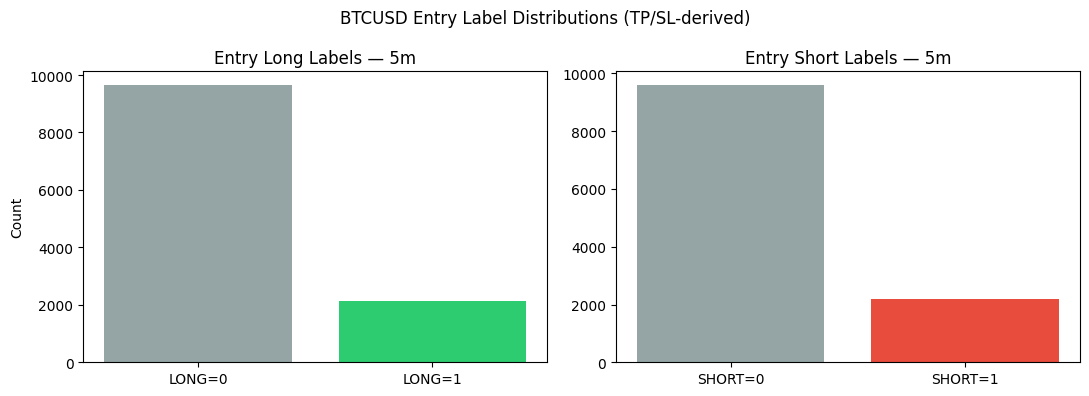

✅ Chart saved.


In [18]:
# ── 4.4  Label distribution chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
tf_show = '5m' if '5m' in CFG.timeframes else CFG.timeframes[0]

# Entry long
lv = ENTRY_LONG_LABELS[tf_show].value_counts().sort_index()
axes[0].bar(['LONG=0','LONG=1'], [int(lv.get(0, 0)), int(lv.get(1, 0))],
            color=['#95a5a6','#2ecc71'])
axes[0].set_title(f'Entry Long Labels — {tf_show}')
axes[0].set_ylabel('Count')

# Entry short
sv = ENTRY_SHORT_LABELS[tf_show].value_counts().sort_index()
axes[1].bar(['SHORT=0','SHORT=1'], [int(sv.get(0, 0)), int(sv.get(1, 0))],
            color=['#95a5a6','#e74c3c'])
axes[1].set_title(f'Entry Short Labels — {tf_show}')

plt.suptitle(f'{CFG.symbol} Entry Label Distributions (TP/SL-derived)')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'label_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Chart saved.')


---
## 5 — Model Training

Two **entry models** per timeframe: binary **LONG** and binary **SHORT** XGBoost classifiers. **No exit model** (live agent uses TP/SL / trailing / time exits).



In [19]:
# ── 5.1  Model builders ───────────────────────────────────────────────────────
def make_entry_model(seed: int, scale_pos_weight: float = 1.0) -> xgb.XGBClassifier:
    # Binary entry classifier used for LONG and SHORT targets.
    return xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
        gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
        objective='binary:logistic',
        eval_metric='aucpr',
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        early_stopping_rounds=30,
        random_state=seed, n_jobs=1, verbosity=0,
    )


def _binary_scale_pos_weight(y: np.ndarray) -> float:
    return float((y == 0).sum()) / max(1, int((y == 1).sum()))


def _print_threshold_sweep(name: str, model: xgb.XGBClassifier, X_va: np.ndarray, y_va: np.ndarray) -> None:
    proba = model.predict_proba(X_va)[:, 1]
    print(f'  {name} validation threshold sweep (precision / recall / F1 pos):')
    for th in (0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80):
        pred = (proba >= th).astype(int)
        p = precision_score(y_va, pred, pos_label=1, zero_division=0)
        r = recall_score(y_va, pred, pos_label=1, zero_division=0)
        f = f1_score(y_va, pred, pos_label=1, zero_division=0)
        print(f'    th={th:.2f}  precision={p:.4f}  recall={r:.4f}  f1_pos={f:.4f}')


print('✅ Model builders defined (entry only).')


✅ Model builders defined (entry only).


In [20]:
# ── 5.2  Train entry models for every timeframe ────────────────────────────────
ENTRY_LONG_MODELS:   Dict[str, Any] = {}
ENTRY_SHORT_MODELS:  Dict[str, Any] = {}
ENTRY_LONG_SCALERS:  Dict[str, Any] = {}
ENTRY_SHORT_SCALERS: Dict[str, Any] = {}
TRAIN_METRICS:  Dict[str, Dict] = {}

for tf in CFG.timeframes:
    print(f'\n── [{tf}] ──────────────────────────────────────────────')

    top_feats = TOP_FEATURES[tf]
    n_safe    = len(ENTRY_LONG_LABELS[tf])
    X_all     = FEATS[tf][top_feats].iloc[:n_safe].values.astype(np.float32)
    y_long    = ENTRY_LONG_LABELS[tf].values
    y_short   = ENTRY_SHORT_LABELS[tf].values

    n      = len(X_all)
    tr_end = int(n * CFG.train_split)
    va_end = int(n * (CFG.train_split + CFG.val_split))

    X_tr, y_l_tr = X_all[:tr_end], y_long[:tr_end]
    X_va, y_l_va = X_all[tr_end:va_end], y_long[tr_end:va_end]
    X_te, y_l_te = X_all[va_end:], y_long[va_end:]
    y_s_tr = y_short[:tr_end]
    y_s_va = y_short[tr_end:va_end]
    y_s_te = y_short[va_end:]

    pos_long_tr = float(y_l_tr.mean())
    pos_short_tr = float(y_s_tr.mean())
    print(f'  Train positive rate  LONG={pos_long_tr:.2%}  SHORT={pos_short_tr:.2%}')
    if pos_long_tr < 0.08 or pos_short_tr < 0.08:
        print('  ⚠️  Low positive rate (<8%) — expect weak recall or unstable PR-AUC; consider more history or label tuning.')

    # ── Scale ───────────────────────────────────────────────────────────────
    l_scaler = RobustScaler().fit(X_tr)
    X_tr_s   = l_scaler.transform(X_tr)
    X_va_s   = l_scaler.transform(X_va)
    X_te_s   = l_scaler.transform(X_te)

    # ── Entry LONG model ────────────────────────────────────────────────────
    spw_l = _binary_scale_pos_weight(y_l_tr)
    l_model = make_entry_model(CFG.random_seed, scale_pos_weight=spw_l)
    l_model.fit(
        X_tr_s, y_l_tr,
        eval_set=[(X_va_s, y_l_va)],
        verbose=False
    )
    if getattr(CFG, 'use_calibration', False):
        cal_l = CalibratedClassifierCV(l_model, method='sigmoid', cv='prefit')
        cal_l.fit(X_va_s, y_l_va)
        l_model = cal_l
    y_l_pred = l_model.predict(X_te_s)
    l_acc    = accuracy_score(y_l_te, y_l_pred)
    l_f1     = f1_score(y_l_te, y_l_pred, zero_division=0)
    l_bacc   = balanced_accuracy_score(y_l_te, y_l_pred)
    l_ap     = average_precision_score(y_l_te, l_model.predict_proba(X_te_s)[:, 1])
    print(f'  Entry LONG  →  acc={l_acc:.4f}  bacc={l_bacc:.4f}  pr_auc={l_ap:.4f}  f1={l_f1:.4f}  (n_test={len(y_l_te)})')
    print('  Entry LONG classification report:')
    print(classification_report(y_l_te, y_l_pred, digits=4, zero_division=0))
    _print_threshold_sweep('Entry LONG', l_model, X_va_s, y_l_va)

    # ── Entry SHORT model ───────────────────────────────────────────────────
    s_scaler = RobustScaler().fit(X_tr)
    X_tr_ss  = s_scaler.transform(X_tr)
    X_va_ss  = s_scaler.transform(X_va)
    X_te_ss  = s_scaler.transform(X_te)
    spw_s = _binary_scale_pos_weight(y_s_tr)
    s_model = make_entry_model(CFG.random_seed + 1, scale_pos_weight=spw_s)
    s_model.fit(
        X_tr_ss, y_s_tr,
        eval_set=[(X_va_ss, y_s_va)],
        verbose=False
    )
    if getattr(CFG, 'use_calibration', False):
        cal_s = CalibratedClassifierCV(s_model, method='sigmoid', cv='prefit')
        cal_s.fit(X_va_ss, y_s_va)
        s_model = cal_s
    y_s_pred = s_model.predict(X_te_ss)
    s_acc    = accuracy_score(y_s_te, y_s_pred)
    s_f1     = f1_score(y_s_te, y_s_pred, zero_division=0)
    s_bacc   = balanced_accuracy_score(y_s_te, y_s_pred)
    s_ap     = average_precision_score(y_s_te, s_model.predict_proba(X_te_ss)[:, 1])
    print(f'  Entry SHORT →  acc={s_acc:.4f}  bacc={s_bacc:.4f}  pr_auc={s_ap:.4f}  f1={s_f1:.4f}  (n_test={len(y_s_te)})')
    print('  Entry SHORT classification report:')
    print(classification_report(y_s_te, y_s_pred, digits=4, zero_division=0))
    _print_threshold_sweep('Entry SHORT', s_model, X_va_ss, y_s_va)

    ENTRY_LONG_MODELS[tf]   = l_model
    ENTRY_SHORT_MODELS[tf]  = s_model
    ENTRY_LONG_SCALERS[tf]  = l_scaler
    ENTRY_SHORT_SCALERS[tf] = s_scaler

    TRAIN_METRICS[tf] = {
        'entry_long_acc': round(l_acc, 4),
        'entry_long_balanced_acc': round(l_bacc, 4),
        'entry_long_pr_auc': round(float(l_ap), 4),
        'entry_long_f1': round(l_f1, 4),
        'entry_short_acc': round(s_acc, 4),
        'entry_short_balanced_acc': round(s_bacc, 4),
        'entry_short_pr_auc': round(float(s_ap), 4),
        'entry_short_f1': round(s_f1, 4),
        'train_pos_rate_long': round(pos_long_tr, 4),
        'train_pos_rate_short': round(pos_short_tr, 4),
        'n_train': tr_end, 'n_test': len(y_l_te),
    }

print('\n✅ All entry models trained.')



── [5m] ──────────────────────────────────────────────
  Train positive rate  LONG=18.43%  SHORT=19.99%
  Entry LONG  →  acc=0.8395  bacc=0.5000  pr_auc=0.2171  f1=0.0000  (n_test=1769)
  Entry LONG classification report:
              precision    recall  f1-score   support

           0     0.8395    1.0000    0.9127      1485
           1     0.0000    0.0000    0.0000       284

    accuracy                         0.8395      1769
   macro avg     0.4197    0.5000    0.4564      1769
weighted avg     0.7047    0.8395    0.7662      1769

  Entry LONG validation threshold sweep (precision / recall / F1 pos):
    th=0.50  precision=0.0000  recall=0.0000  f1_pos=0.0000
    th=0.55  precision=0.0000  recall=0.0000  f1_pos=0.0000
    th=0.60  precision=0.0000  recall=0.0000  f1_pos=0.0000
    th=0.65  precision=0.0000  recall=0.0000  f1_pos=0.0000
    th=0.70  precision=0.0000  recall=0.0000  f1_pos=0.0000
    th=0.75  precision=0.0000  recall=0.0000  f1_pos=0.0000
    th=0.80  precis

### Training verification (Colab ↔ repo)

- **Sync:** Use this checked-in notebook (or the same git revision) for runs that produce deployable `.joblib` exports. Avoid one-off Colab copies that drift from the repo.
- **Calibration:** Default is **off** (raw XGB). When **`CFG.use_calibration = True`**, long/short heads use **`CalibratedClassifierCV(..., method='sigmoid', cv='prefit')`**. Do **not** switch to **`isotonic`** here (sparse positives + isotonic often collapse calibrated probabilities).
- **Class imbalance:** **`scale_pos_weight`** is set via **`_binary_scale_pos_weight`** and **`make_entry_model`** — keep it; removing it reproduces the failure mode described in external reports.

**Optional experiment (only if probabilities stay degenerate after verified sigmoid + SPW):** set **`CFG.label_mode = 'hybrid'`** in a **separate** retrain branch—do not mix those artifacts with standard TP/SL runs.


In [ ]:
# ── 5.2b  Validation probability diagnostics (positive class, label=1) ───────
# Min/max/percentiles help spot calibration collapse (e.g. max proba < runtime gates).
# Optional "raw XGB" lines repeat inference with the uncalibrated base estimator inside CalibratedClassifierCV.
# Results are stored in PROBA_DIAGNOSTICS + PROBA_THRESHOLD_HINTS for export metadata traceability.
from sklearn.calibration import CalibratedClassifierCV


def _proba_stats(probs: np.ndarray) -> Dict[str, float]:
    probs = np.asarray(probs, dtype=float).ravel()
    if probs.size == 0:
        return {
            "min": 0.0,
            "max": 0.0,
            "mean": 0.0,
            "std": 0.0,
            "p50": 0.0,
            "p80": 0.0,
            "p95": 0.0,
        }
    return {
        "min": float(probs.min()),
        "max": float(probs.max()),
        "mean": float(probs.mean()),
        "std": float(probs.std()),
        "p50": float(np.percentile(probs, 50)),
        "p80": float(np.percentile(probs, 80)),
        "p95": float(np.percentile(probs, 95)),
    }


def _fmt_stats(s: Dict[str, float]) -> str:
    return (
        f"min={s['min']:.4f} max={s['max']:.4f} mean={s['mean']:.4f} std={s['std']:.4f} "
        f"P50={s['p50']:.4f} P80={s['p80']:.4f} P95={s['p95']:.4f}"
    )


def _raw_estimator_from_calibrated(m: Any) -> Any:
    if not isinstance(m, CalibratedClassifierCV):
        return None
    cc0 = m.calibrated_classifiers_[0]
    return getattr(cc0, "estimator", None) or getattr(cc0, "base_estimator", None)


PROBA_DIAGNOSTICS: Dict[str, Dict[str, Any]] = {}
PROBA_THRESHOLD_HINTS: Dict[str, Dict[str, float]] = {}

print("=== Validation split: predict_proba for class 1 (LONG / SHORT heads) ===\n")
for tf in CFG.timeframes:
    top_feats = TOP_FEATURES[tf]
    n_safe = len(ENTRY_LONG_LABELS[tf])
    X_all = FEATS[tf][top_feats].iloc[:n_safe].values.astype(np.float32)
    y_long = ENTRY_LONG_LABELS[tf].values
    y_short = ENTRY_SHORT_LABELS[tf].values
    n = len(X_all)
    tr_end = int(n * CFG.train_split)
    va_end = int(n * (CFG.train_split + CFG.val_split))
    X_va = X_all[tr_end:va_end]
    y_l_va = y_long[tr_end:va_end]
    y_s_va = y_short[tr_end:va_end]

    l_sc = ENTRY_LONG_SCALERS[tf]
    s_sc = ENTRY_SHORT_SCALERS[tf]
    X_va_ls = l_sc.transform(X_va)
    X_va_ss = s_sc.transform(X_va)

    lm = ENTRY_LONG_MODELS[tf]
    sm = ENTRY_SHORT_MODELS[tf]
    pl = lm.predict_proba(X_va_ls)[:, 1]
    ps = sm.predict_proba(X_va_ss)[:, 1]
    l_stats = _proba_stats(pl)
    s_stats = _proba_stats(ps)

    tf_diag: Dict[str, Any] = {
        "validation_size": int(len(pl)),
        "long_pos_rate": float(y_l_va.mean()),
        "short_pos_rate": float(y_s_va.mean()),
        "long_calibrated": l_stats,
        "short_calibrated": s_stats,
    }

    print(f"[{tf}] LONG  (calibrated):  {_fmt_stats(l_stats)}  | n_va={len(pl)} pos_rate={y_l_va.mean():.2%}")
    print(f"[{tf}] SHORT (calibrated): {_fmt_stats(s_stats)}  | n_va={len(ps)} pos_rate={y_s_va.mean():.2%}")

    if getattr(CFG, "use_calibration", False):
        raw_l = _raw_estimator_from_calibrated(lm)
        raw_s = _raw_estimator_from_calibrated(sm)
        if raw_l is not None:
            try:
                pr_l = raw_l.predict_proba(X_va_ls)[:, 1]
                raw_l_stats = _proba_stats(pr_l)
                tf_diag["long_raw_xgb"] = raw_l_stats
                print(f"[{tf}] LONG  (raw XGB):     {_fmt_stats(raw_l_stats)}")
            except Exception as e:
                print(f"[{tf}] LONG  raw XGB skipped: {e}")
        if raw_s is not None:
            try:
                pr_s = raw_s.predict_proba(X_va_ss)[:, 1]
                raw_s_stats = _proba_stats(pr_s)
                tf_diag["short_raw_xgb"] = raw_s_stats
                print(f"[{tf}] SHORT (raw XGB):    {_fmt_stats(raw_s_stats)}")
            except Exception as e:
                print(f"[{tf}] SHORT raw XGB skipped: {e}")

    # Runtime threshold hints (starting points): choose in calibrated distribution tail.
    # Final values should be confirmed in simulator/live dry-runs.
    tf_hints = {
        "mtf_entry_min_buy_prob": round(float(l_stats["p95"]), 4),
        "mtf_entry_min_sell_prob": round(float(s_stats["p95"]), 4),
        "mtf_trend_min_buy_prob": round(float(max(l_stats["p80"], l_stats["mean"])) , 4),
        "mtf_trend_min_sell_prob": round(float(max(s_stats["p80"], s_stats["mean"])) , 4),
    }
    PROBA_DIAGNOSTICS[tf] = tf_diag
    PROBA_THRESHOLD_HINTS[tf] = tf_hints

    print(f"[{tf}] threshold hints: {tf_hints}")
    print()


In [21]:
# ── 5.3  Training summary ─────────────────────────────────────────────────────
rows = []
for tf, m in TRAIN_METRICS.items():
    rows.append({'TF': tf, **m})
summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))


 TF  entry_long_acc  entry_long_balanced_acc  entry_long_pr_auc  entry_long_f1  entry_short_acc  entry_short_balanced_acc  entry_short_pr_auc  entry_short_f1  train_pos_rate_long  train_pos_rate_short  n_train  n_test
 5m          0.8395                   0.5000             0.2171            0.0           0.8282                       0.5              0.2288             0.0               0.1843                0.1999     8253    1769
15m          0.7483                   0.4995             0.3529            0.0           0.7612                       0.5              0.3193             0.0               0.1698                0.1915     6855    1470


---
## 6 — Walk-Forward Validation

In [22]:
# ── 6.1  TimeSeriesSplit walk-forward (long + short heads, combined-signal Sharpe) ──
WF_RESULTS: Dict[str, List[Dict]] = {}

for tf in CFG.timeframes:
    print(f'\n  [{tf}]  walk-forward ({CFG.n_folds} folds) …')

    top_feats = TOP_FEATURES[tf]
    n_safe    = len(ENTRY_LONG_LABELS[tf])
    X_all     = FEATS[tf][top_feats].iloc[:n_safe].values.astype(np.float32)
    y_long    = ENTRY_LONG_LABELS[tf].values
    y_short   = ENTRY_SHORT_LABELS[tf].values
    close_arr = PRICES[tf]['close'].iloc[:n_safe].values

    tscv   = TimeSeriesSplit(n_splits=CFG.n_folds)
    folds  = []

    for fold, (tri, tei) in enumerate(tscv.split(X_all)):
        X_tr, X_te = X_all[tri], X_all[tei]
        y_tr_l, y_te_l = y_long[tri], y_long[tei]
        y_tr_s, y_te_s = y_short[tri], y_short[tei]

        l_scaler = RobustScaler().fit(X_tr)
        X_tr_ls = l_scaler.transform(X_tr)
        X_te_ls = l_scaler.transform(X_te)

        s_scaler = RobustScaler().fit(X_tr)
        X_tr_ss = s_scaler.transform(X_tr)
        X_te_ss = s_scaler.transform(X_te)

        val_split = int(len(X_tr_ls) * 0.9)

        spw_l = float((y_tr_l == 0).sum()) / max(1, int((y_tr_l == 1).sum()))
        m_long = xgb.XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            objective='binary:logistic',
            eval_metric='aucpr',
            scale_pos_weight=spw_l,
            use_label_encoder=False,
            early_stopping_rounds=30,
            random_state=CFG.random_seed, n_jobs=-1, verbosity=0
        )
        m_long.fit(
            X_tr_ls[:val_split], y_tr_l[:val_split],
            eval_set=[(X_tr_ls[val_split:], y_tr_l[val_split:])],
            verbose=False
        )

        spw_s = float((y_tr_s == 0).sum()) / max(1, int((y_tr_s == 1).sum()))
        m_short = xgb.XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            objective='binary:logistic',
            eval_metric='aucpr',
            scale_pos_weight=spw_s,
            use_label_encoder=False,
            early_stopping_rounds=30,
            random_state=CFG.random_seed + 1, n_jobs=-1, verbosity=0
        )
        m_short.fit(
            X_tr_ss[:val_split], y_tr_s[:val_split],
            eval_set=[(X_tr_ss[val_split:], y_tr_s[val_split:])],
            verbose=False
        )

        preds_l = m_long.predict(X_te_ls)
        acc     = accuracy_score(y_te_l, preds_l)
        f1_m    = f1_score(y_te_l, preds_l, average='macro', zero_division=0)
        ap_l    = average_precision_score(y_te_l, m_long.predict_proba(X_te_ls)[:, 1])
        ap_s    = average_precision_score(y_te_s, m_short.predict_proba(X_te_ss)[:, 1])

        long_p = m_long.predict_proba(X_te_ls)[:, 1]
        short_p = m_short.predict_proba(X_te_ss)[:, 1]
        signal = np.where(
            (long_p >= 0.5) & (long_p > short_p), 1.0,
            np.where((short_p >= 0.5) & (short_p > long_p), -1.0, 0.0)
        )

        c_te     = close_arr[tei]
        nh       = min(len(signal), len(c_te) - 1)
        fwd_ret  = np.log(c_te[1:nh+1] / c_te[:nh] + 1e-10)
        strat    = signal[:nh] * fwd_ret
        sharpe   = (strat.mean() / (strat.std() + 1e-10) * np.sqrt(252))

        folds.append({
            'fold': fold+1, 'n_train': len(tri), 'n_test': len(tei),
            'accuracy': round(acc, 4), 'f1_macro': round(f1_m, 4),
            'ap_long': round(float(ap_l), 4), 'ap_short': round(float(ap_s), 4),
            'sharpe': round(float(sharpe), 4),
        })
        print(
            f'    Fold {fold+1}  acc={acc:.4f}  f1={f1_m:.4f}  '
            f'ap_long={ap_l:.4f}  ap_short={ap_s:.4f}  sharpe={sharpe:.4f}'
        )

    WF_RESULTS[tf] = folds

print('\n✅ Walk-forward validation complete.')



  [5m]  walk-forward (5 folds) …
    Fold 1  acc=0.5033  f1=0.4351  ap_long=0.2181  ap_short=0.1906  sharpe=0.3795
    Fold 2  acc=0.6377  f1=0.5086  ap_long=0.2310  ap_short=0.2378  sharpe=-0.2716
    Fold 3  acc=0.6875  f1=0.5505  ap_long=0.2996  ap_short=0.2528  sharpe=0.1901
    Fold 4  acc=0.2534  f1=0.2510  ap_long=0.2927  ap_short=0.2058  sharpe=-0.4434
    Fold 5  acc=0.7623  f1=0.5375  ap_long=0.2317  ap_short=0.1504  sharpe=0.3391

  [15m]  walk-forward (5 folds) …
    Fold 1  acc=0.6801  f1=0.5087  ap_long=0.1005  ap_short=0.1730  sharpe=0.0278
    Fold 2  acc=0.7812  f1=0.6102  ap_long=0.2493  ap_short=0.2310  sharpe=0.0005
    Fold 3  acc=0.3425  f1=0.2994  ap_long=0.3526  ap_short=0.3461  sharpe=-0.5015
    Fold 4  acc=0.4669  f1=0.4643  ap_long=0.3789  ap_short=0.3060  sharpe=0.3819
    Fold 5  acc=0.5864  f1=0.5532  ap_long=0.3443  ap_short=0.2985  sharpe=0.0599

✅ Walk-forward validation complete.


In [23]:
# ── 6.2  Summary table + chart ───────────────────────────────────────────────
rows = []
for tf, folds in WF_RESULTS.items():
    for f in folds:
        rows.append({'timeframe': tf, **f})
wf_df = pd.DataFrame(rows)

cols_mean = ['accuracy', 'f1_macro', 'ap_long', 'ap_short', 'sharpe']
summary_wf = wf_df.groupby('timeframe')[cols_mean].mean().round(4).reset_index()
print('Walk-forward mean metrics (Sharpe = combined long+short prob signal × 1-bar log return):')
print(summary_wf.to_string(index=False))

fig = px.box(
    wf_df, x='timeframe', y='sharpe', color='timeframe',
    title='Walk-Forward Combined-Signal Sharpe by Timeframe (long+short heads)',
    points='all', template='plotly_dark'
)
fig.show()
fig.write_html(str(REPORT_DIR / 'walk_forward_sharpe.html'))
print('✅ Chart saved.')


Walk-forward mean metrics (Sharpe = combined long+short prob signal × 1-bar log return):
timeframe  accuracy  f1_macro  ap_long  ap_short  sharpe
      15m    0.5714    0.4872   0.2851    0.2709 -0.0063
       5m    0.5688    0.4565   0.2546    0.2075  0.0387


✅ Chart saved.


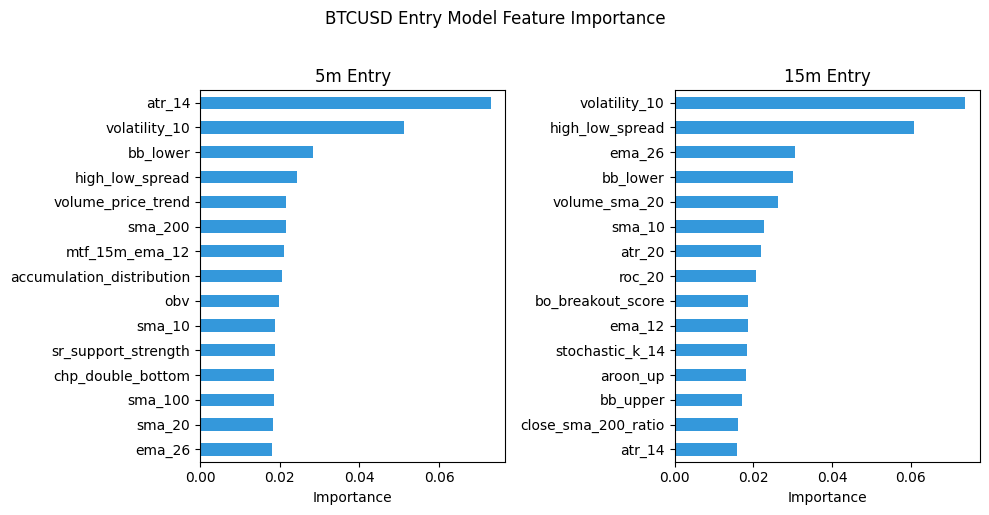

✅ Feature importance saved.


In [25]:
# ── 6.3  Feature importance plot (top 15 features per TF) ────────────────────
fig, axes = plt.subplots(1, len(CFG.timeframes), figsize=(5*len(CFG.timeframes), 5))
if len(CFG.timeframes) == 1:
    axes = [axes]

for ax, tf in zip(axes, CFG.timeframes):
    m     = ENTRY_LONG_MODELS[tf]
    feats = TOP_FEATURES[tf]
    # Check if the model is calibrated and adjust how feature importances are accessed
    if isinstance(m, CalibratedClassifierCV):
        imp   = pd.Series(m.estimator.feature_importances_, index=feats).nlargest(15)
    else:
        imp   = pd.Series(m.feature_importances_, index=feats).nlargest(15)
    imp.plot(kind='barh', ax=ax, color='#3498db')
    ax.set_title(f'{tf} Entry')
    ax.set_xlabel('Importance')
    ax.invert_yaxis()

plt.suptitle(f'{CFG.symbol} Entry Model Feature Importance', y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Feature importance saved.')

In [27]:
# ── 5.4  Feature importance sanity (pattern features) ─────────────────────────
# If pattern importance stays near-zero, run an ablation pass with
# include_pattern_features=False and compare walk-forward metrics.
PATTERN_PREFIXES = ('cdl_', 'chp_', 'sr_', 'tl_', 'bo_')
for tf in CFG.timeframes:
    m = ENTRY_LONG_MODELS[tf]
    feats = TOP_FEATURES[tf]
    # Check if the model is calibrated and adjust how feature importances are accessed
    if isinstance(m, CalibratedClassifierCV):
        imp = pd.Series(m.estimator.feature_importances_, index=feats)
    else:
        imp = pd.Series(m.feature_importances_, index=feats)
    pattern_imp = imp[[f for f in feats if any(f.startswith(p) for p in PATTERN_PREFIXES)]]
    if len(pattern_imp) > 0:
        top_pat = pattern_imp.nlargest(5)
        print(f'  [{tf}] Top pattern features: {list(top_pat.index)}')
        if pattern_imp.sum() < 0.01:
            print(f'    ⚠️  Pattern features have near-zero total importance ({pattern_imp.sum():.4f})')

  [5m] Top pattern features: ['sr_support_strength', 'chp_double_bottom', 'sr_resistance_strength', 'tl_trend_slope', 'sr_resistance_dist_pct']
  [15m] Top pattern features: ['bo_breakout_score', 'tl_trend_slope', 'tl_uptrend_detected', 'chp_double_top', 'cdl_body_ratio']


**Local storage:** After downloading the ZIP, extract its contents into:
`agent/model_storage/jacksparrow_v5_BTCUSD_YYYY-MM-DD/`

Then set `MODEL_DIR=./agent/model_storage/jacksparrow_v5_BTCUSD_YYYY-MM-DD` in `.env`.

**Post-deploy checks (required):**
1. `pytest tests/unit/test_feature_parity.py -q`
2. `python scripts/test_model_inference.py --model-dir agent/model_storage/jacksparrow_v5_BTCUSD_YYYY-MM-DD`

---
## 7 — Export & Download

Saves all models + metadata and creates a downloadable ZIP.

In [28]:
# ── 7.1  Dataset fingerprint ──────────────────────────────────────────────────
def sha256_df(df: pd.DataFrame) -> str:
    arr = df[['open','high','low','close','volume']].values.astype(np.float64)
    return hashlib.sha256(arr.tobytes()).hexdigest()[:16]

DATA_HASHES = {tf: sha256_df(RAW[tf]) for tf in CFG.timeframes}
for tf, h in DATA_HASHES.items():
    print(f'  [{tf}]  sha256={h}')
print('✅ Hashes computed.')


  [5m]  sha256=6b636402fe1452af
  [15m]  sha256=005b7326fe8a442d
✅ Hashes computed.


In [29]:
# ── 7.2  Save models + metadata (versioned folder for local storage) ─────────
import sys
import sklearn, xgboost

# Versioned folder: extract to agent/model_storage/jacksparrow_v5_BTCUSD_YYYY-MM-DD
EXPORT_VERSION = '5.0.0'
EXPORT_DATE = datetime.now().strftime('%Y-%m-%d')
EXPORT_DIR = BASE / 'models' / f'jacksparrow_v5_{CFG.symbol}_{EXPORT_DATE}'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Export folder: {EXPORT_DIR}')

if 'PROBA_DIAGNOSTICS' not in globals():
    PROBA_DIAGNOSTICS = {}
if 'PROBA_THRESHOLD_HINTS' not in globals():
    PROBA_THRESHOLD_HINTS = {}

for tf in CFG.timeframes:
    tag = f'{CFG.symbol}_{tf}'
    print(f'  Saving [{tag}] …')

    joblib.dump(ENTRY_LONG_MODELS[tf],   EXPORT_DIR / f'entry_long_model_{tag}.joblib')
    joblib.dump(ENTRY_LONG_SCALERS[tf],  EXPORT_DIR / f'entry_long_scaler_{tag}.joblib')
    joblib.dump(ENTRY_SHORT_MODELS[tf],  EXPORT_DIR / f'entry_short_model_{tag}.joblib')
    joblib.dump(ENTRY_SHORT_SCALERS[tf], EXPORT_DIR / f'entry_short_scaler_{tag}.joblib')

    # Feature names: strict train-serve parity contract.
    if list(FEATS[tf].columns) != list(EXPANDED_FEATURE_LIST):
        raise ValueError(
            f'[{tf}] feature order mismatch before export; train/live parity broken.'
        )
    with open(EXPORT_DIR / f'features_{tag}.json', 'w') as f:
        json.dump({'features': list(EXPANDED_FEATURE_LIST)}, f, indent=2)

    wf_mean = (
        pd.DataFrame(WF_RESULTS[tf])[['accuracy', 'f1_macro', 'ap_long', 'ap_short', 'sharpe']]
        .mean().round(4).to_dict()
    )

    yl = ENTRY_LONG_LABELS[tf]
    ys = ENTRY_SHORT_LABELS[tf]
    label_stats = {
        'n_samples': int(len(yl)),
        'long_positive_rate': round(float(yl.mean()), 4),
        'short_positive_rate': round(float(ys.mean()), 4),
    }

    metadata = {
        'model_name':    f'jacksparrow_{tag}',
        'version':       EXPORT_VERSION,
        'symbol':        CFG.symbol,
        'timeframe':     tf,
        'trained_at':    datetime.now(timezone.utc).isoformat(),
        'dataset_sha256': DATA_HASHES[tf],
        'config_sha256': hashlib.sha256(json.dumps(asdict(CFG), sort_keys=True, default=str).encode('utf-8')).hexdigest()[:16],
        'dataset_range': {
            'from':    str(RAW[tf]['timestamp'].iloc[0]),
            'to':      str(RAW[tf]['timestamp'].iloc[-1]),
            'candles': len(RAW[tf]),
        },
        'training_authority': 'notebook_inline_colab',
        'calibration': {
            'use_calibration': bool(getattr(CFG, 'use_calibration', False)),
            'method': 'sigmoid' if getattr(CFG, 'use_calibration', False) else 'none',
            'cv': 'prefit' if getattr(CFG, 'use_calibration', False) else 'none',
        },
        'probability_diagnostics': PROBA_DIAGNOSTICS.get(tf, {}),
        'runtime_threshold_hints': PROBA_THRESHOLD_HINTS.get(tf, {}),
        'features':        list(EXPANDED_FEATURE_LIST),
        'features_required': list(EXPANDED_FEATURE_LIST),
        'n_features':      len(EXPANDED_FEATURE_LIST),
        'signal_classes':  {'entry': {'long': {'0': 'NO_LONG', '1': 'LONG'},
                                       'short': {'0': 'NO_SHORT', '1': 'SHORT'}}},
        'train_metrics':   TRAIN_METRICS[tf],
        'walkforward_mean': wf_mean,
        'label_strategy': 'tp_sl_first_hit_fee_aware',
        'label_strategy_notes': (
            'Default: agent-aligned TP/SL (0.3%/0.25%) with extended entry_lookahead_map for more positives. '
            'Alternatives: lower TP/SL in training AND agent env together; hybrid return-based auxiliary targets.'
        ),
        'label_stats': label_stats,
        'exit_policy_note': 'Live agent: TP/SL + trailing + max hold; no ML exit artefact in this export.',
        'config': {
            'entry_tp_pct':     TP_PCT,
            'entry_sl_pct':     SL_PCT,
            'entry_fee_pct':    FEE_PCT,
            'entry_max_bars':   ENTRY_MAX_BARS[tf],
            'seed':             CFG.random_seed,
            'timeframes':       list(CFG.timeframes),
        },
        'library_versions': {
            'python':   sys.version.split()[0],
            'xgboost':  xgboost.__version__,
            'sklearn':  sklearn.__version__,
            'numpy':    np.__version__,
            'pandas':   pd.__version__,
        },
        'artifacts': {
            'entry_long_model':  f'entry_long_model_{tag}.joblib',
            'entry_long_scaler': f'entry_long_scaler_{tag}.joblib',
            'entry_short_model':  f'entry_short_model_{tag}.joblib',
            'entry_short_scaler': f'entry_short_scaler_{tag}.joblib',
            'features':     f'features_{tag}.json',
            'metadata':     f'metadata_{tag}.json',
        }
    }
    with open(EXPORT_DIR / f'metadata_{tag}.json', 'w') as f:
        json.dump(metadata, f, indent=2, default=str)

    n_files = len(list(EXPORT_DIR.glob(f'*{tag}*')))
    print(f'    ✅ {n_files} artifacts saved for [{tag}]')

print('\n✅ All models exported.')


Export folder: /content/JackSparrow/models/jacksparrow_v5_BTCUSD_2026-03-21
  Saving [BTCUSD_5m] …
    ✅ 6 artifacts saved for [BTCUSD_5m]
  Saving [BTCUSD_15m] …
    ✅ 6 artifacts saved for [BTCUSD_15m]

✅ All models exported.


In [30]:
# ── 7.3  Validate saved artifacts ─────────────────────────────────────────────
print('Validating artifacts …\n')
errors = []
for f in sorted(EXPORT_DIR.iterdir()):
    try:
        if f.suffix == '.joblib':
            obj = joblib.load(f)
            print(f'  ✓ {f.name:<55}  {type(obj).__name__}')
        elif f.suffix == '.json':
            with open(f) as fh:
                d = json.load(fh)
            print(f'  ✓ {f.name:<55}  {len(d)} keys')
    except Exception as e:
        errors.append(f.name)
        print(f'  ✗ {f.name}: {e}')

status = '✅ All OK' if not errors else f'❌ Errors: {errors}'
print(f'\n{status}')


Validating artifacts …

  ✓ entry_long_model_BTCUSD_15m.joblib                       CalibratedClassifierCV
  ✓ entry_long_model_BTCUSD_5m.joblib                        CalibratedClassifierCV
  ✓ entry_long_scaler_BTCUSD_15m.joblib                      RobustScaler
  ✓ entry_long_scaler_BTCUSD_5m.joblib                       RobustScaler
  ✓ entry_short_model_BTCUSD_15m.joblib                      CalibratedClassifierCV
  ✓ entry_short_model_BTCUSD_5m.joblib                       CalibratedClassifierCV
  ✓ entry_short_scaler_BTCUSD_15m.joblib                     RobustScaler
  ✓ entry_short_scaler_BTCUSD_5m.joblib                      RobustScaler
  ✓ features_BTCUSD_15m.json                                 1 keys
  ✓ features_BTCUSD_5m.json                                  1 keys
  ✓ metadata_BTCUSD_15m.json                                 22 keys
  ✓ metadata_BTCUSD_5m.json                                  22 keys

✅ All OK


In [31]:
# ── 7.4  Create ZIP and download ──────────────────────────────────────────────
zip_name = f'jacksparrow_models_v5_{CFG.symbol}_{EXPORT_DATE}.zip'
zip_path = BASE / zip_name

# Create zip of the versioned export folder
shutil.make_archive(str(BASE / zip_name.replace('.zip','')), 'zip', EXPORT_DIR)
print(f'✅ ZIP created: {zip_path}  ({zip_path.stat().st_size / 1024:.0f} KB)')

# ── Download (Colab only) ─────────────────────────────────────────────────────
if IN_COLAB:
    from google.colab import files
    files.download(str(zip_path))
    print('✅ Download started.')
else:
    print(f'📦 ZIP ready at: {zip_path}')


✅ ZIP created: /content/JackSparrow/jacksparrow_models_v5_BTCUSD_2026-03-21.zip  (128 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started.


In [32]:
# ── 7.5  Training summary ─────────────────────────────────────────────────────
print('\n' + '='*70)
print('🏴‍☠️  JackSparrow v5 — Training Complete')
print('='*70)
print(f'Symbol:       {CFG.symbol}')
print(f'Timeframes:   {CFG.timeframes}')
print(f'Models saved: {len(list(EXPORT_DIR.glob("*.joblib")))} .joblib files (entry long+short per TF; no ML exit)')
print()
print('Per-timeframe results (WF Sharpe = combined long+short signal proxy):')
hdr = f'  {"TF":<6} {"L_acc":>7} {"L_PR":>7} {"L_F1":>7} {"S_acc":>7} {"S_PR":>7} {"S_F1":>7} {"WF_Sh":>7}'
print(hdr)
print(f'  {"-"*6} {"-"*7} {"-"*7} {"-"*7} {"-"*7} {"-"*7} {"-"*7} {"-"*7}')
for tf in CFG.timeframes:
    m  = TRAIN_METRICS[tf]
    wf = pd.DataFrame(WF_RESULTS[tf])['sharpe'].mean()
    print(
        f'  {tf:<6} {m["entry_long_acc"]:>7.4f} {m["entry_long_pr_auc"]:>7.4f} {m["entry_long_f1"]:>7.4f} '
        f'{m["entry_short_acc"]:>7.4f} {m["entry_short_pr_auc"]:>7.4f} {m["entry_short_f1"]:>7.4f} {wf:>7.4f}'
    )
print()
print(f'ZIP: {zip_path}')
print('Optional: python scripts/trade_simulator.py --csv <ohlcv.csv> --tp 0.006 --sl 0.004')
print('='*70)



🏴‍☠️  JackSparrow v5 — Training Complete
Symbol:       BTCUSD
Timeframes:   ['5m', '15m']
Models saved: 8 .joblib files (entry long+short per TF; no ML exit)

Per-timeframe results (WF Sharpe = combined long+short signal proxy):
  TF       L_acc    L_PR    L_F1   S_acc    S_PR    S_F1   WF_Sh
  ------ ------- ------- ------- ------- ------- ------- -------
  5m      0.8395  0.2171  0.0000  0.8282  0.2288  0.0000  0.0387
  15m     0.7483  0.3529  0.0000  0.7612  0.3193  0.0000 -0.0063

ZIP: /content/JackSparrow/jacksparrow_models_v5_BTCUSD_2026-03-21.zip
Optional: python scripts/trade_simulator.py --csv <ohlcv.csv> --tp 0.006 --sl 0.004
